<a href="https://colab.research.google.com/github/HimanshiChoubal/Machine_Learning_lab/blob/main/Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.preprocessing import StandardScaler #standardizing features so they have a mean of 0 and variance of 1
from sklearn.metrics import silhouette_score, davies_bouldin_score #mathematically measure how "good" our clusters are
from scipy.cluster.hierarchy import dendrogram, linkage

# Load dataset (Iris)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
column_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
df = pd.read_csv(url, names=column_names)

# Prepare features (Drop the target label for unsupervised learning)
X = df.drop('species', axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Dataset loaded and scaled successfully.")

Dataset loaded and scaled successfully.


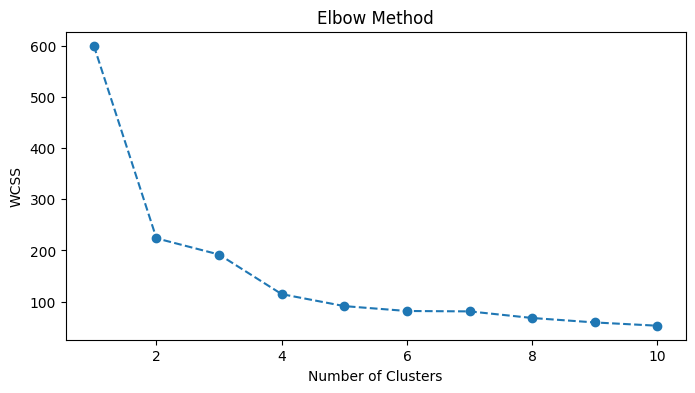

K-Means Silhouette Score: 0.4787
K-Means Davies-Bouldin Index: 0.7868


In [2]:
# --- 2. Elbow Method to find optimal K ---
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42) #random_state=This ensures that every time you run your code, the train_test_split function (or other randomized algorithms) produces the exact same output.
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_) # Within Cluster sum of squares

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

# --- 1. K-Means Implementation (Optimal K=3 for Iris) ---
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

# Evaluation Metrics
sil_kmeans = silhouette_score(X_scaled, y_kmeans)
db_kmeans = davies_bouldin_score(X_scaled, y_kmeans)

print(f"K-Means Silhouette Score: {sil_kmeans:.4f}")
print(f"K-Means Davies-Bouldin Index: {db_kmeans:.4f}")

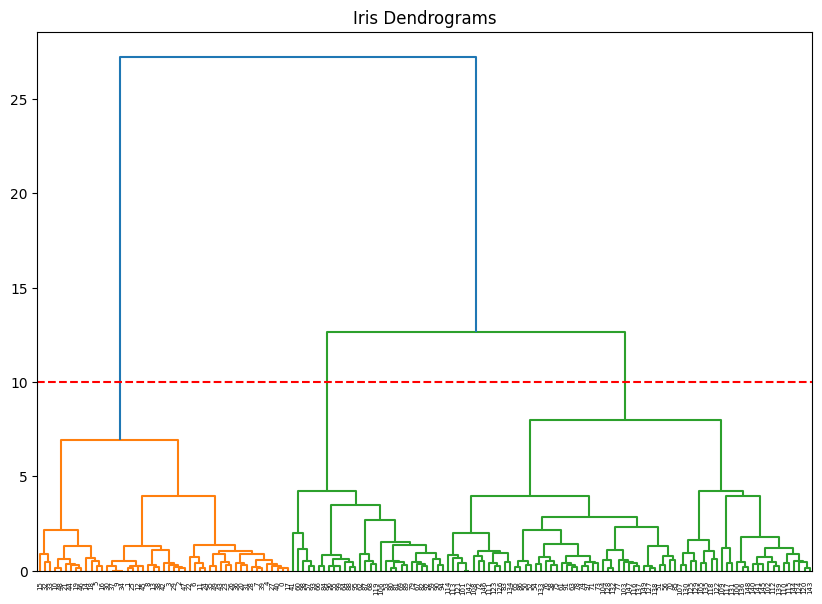

Hierarchical Clustering Silhouette Score: 0.4455


In [4]:
# --- 3. Dendrogram ---
plt.figure(figsize=(10, 7))
plt.title("Iris Dendrograms")
# Using 'ward' linkage to minimize variance within clusters
link = linkage(X_scaled, method='ward')
dend = dendrogram(link)
plt.axhline(y=10, color='r', linestyle='--') # Cut line
plt.show()

# --- 3a. Forming clusters by cutting the dendrogram ---
# Based on the dendrogram, we cut at a level that gives us 3 clusters
hc = AgglomerativeClustering(n_clusters=3, linkage='ward')
y_hc = hc.fit_predict(X_scaled)

# Quality Measurement
sil_hc = silhouette_score(X_scaled, y_hc)
print(f"Hierarchical Clustering Silhouette Score: {sil_hc:.4f}")

Estimated number of clusters: 2
Estimated number of noise points: 35


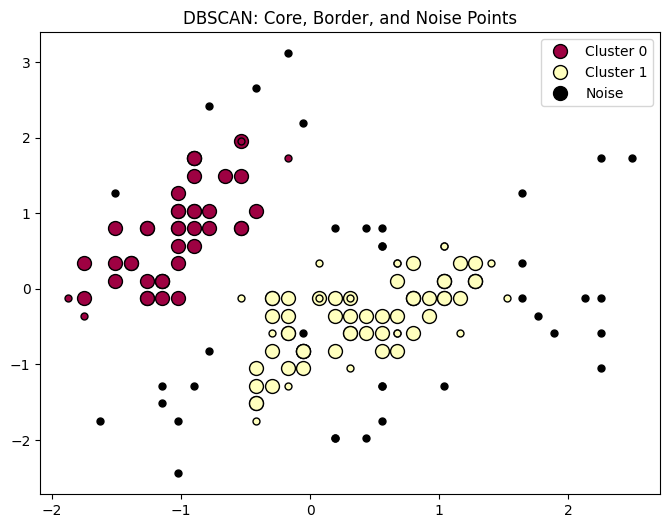

In [5]:
# --- 4. DBSCAN Implementation ---
# eps: distance to search for neighbors, min_samples: min points to form a cluster
dbscan = DBSCAN(eps=0.5, min_samples=5)
y_dbscan = dbscan.fit_predict(X_scaled)

# Identify point types
core_samples_mask = np.zeros_like(dbscan.labels_, dtype=bool)
core_samples_mask[dbscan.core_sample_indices_] = True
labels = dbscan.labels_

# Categorizing points
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print(f'Estimated number of clusters: {n_clusters_}')
print(f'Estimated number of noise points: {n_noise_}')

# Visualization of DBSCAN
plt.figure(figsize=(8,6))
unique_labels = set(labels)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

for k, col in zip(unique_labels, colors):
    if k == -1:
        col = [0, 0, 0, 1] # Black for noise

    class_member_mask = (labels == k)

    # Plot Core Points
    xy = X_scaled[class_member_mask & core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col), markeredgecolor='k', markersize=10, label=f'Cluster {k}' if k != -1 else 'Noise')

    # Plot Border Points
    xy = X_scaled[class_member_mask & ~core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col), markeredgecolor='k', markersize=5)

plt.title('DBSCAN: Core, Border, and Noise Points')
plt.legend()
plt.show()


--- Performance Comparison Table ---
                                Metric   K-Means  Hierarchical    DBSCAN
0  Silhouette Score (Higher is better)  0.478724       0.44554  0.349198
1     Davies-Bouldin (Lower is better)  0.786801       0.80594  6.160798


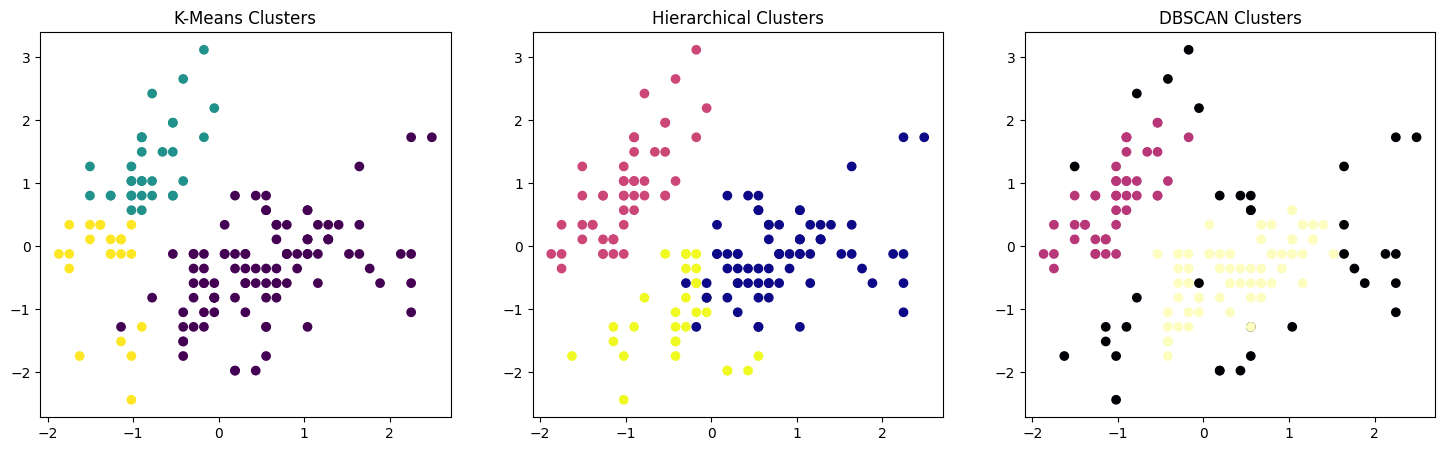

In [6]:
# Comparison Table
comparison_data = {
    "Metric": ["Silhouette Score (Higher is better)", "Davies-Bouldin (Lower is better)"],
    "K-Means": [sil_kmeans, db_kmeans],
    "Hierarchical": [sil_hc, davies_bouldin_score(X_scaled, y_hc)],
    "DBSCAN": [silhouette_score(X_scaled, y_dbscan) if n_clusters_ > 0 else "N/A",
               davies_bouldin_score(X_scaled, y_dbscan) if n_clusters_ > 0 else "N/A"]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n--- Performance Comparison Table ---")
print(comparison_df)

# Visualizing Comparison of Clusters
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_kmeans, cmap='viridis')
axes[0].set_title('K-Means Clusters')

axes[1].scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_hc, cmap='plasma')
axes[1].set_title('Hierarchical Clusters')

axes[2].scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_dbscan, cmap='magma')
axes[2].set_title('DBSCAN Clusters')

plt.show()